# MINRES: in between GMRES and CG
Name: Dylan Carter   
Date: 19.01.2026  

**Part 1:** First we will introduce the Arnoldi process and GMRES, explain what a Krylov subspace is, how a basis is generated, and what subproblem is solved at each iteration.

# The Arnoldi Process and GMRES Algorithm

The Generalized Minimal Residual (GMRES) method is an iterative algorithm for solving linear systems $Ax = b$ where $A$ is a large, sparse, nonsymmetric matrix. GMRES uses the Arnoldi process to build an orthogonal basis for the Krylov subspace. The Krylov subspace for matrix $A$ and vector $b$ is defined as follows:

$$
\mathcal{K}_k(A, b) = \text{span}\{b, Ab, A^2b, \ldots, A^{k-1}b\}
$$

The Arnoldi method generates an orthogonal basis $\{q_1, q_2, \ldots, q_k\}$ for the Krylov subspace.

## Arnoldi Algorithm

**Initialize:**
$$
q_1 = b / \|b\|_2
$$

**For** $j = 1, 2, \ldots, k-1$:
1. $v = Aq_j$
2. **For** $i = 1, \ldots, j$:
   - $h_{ij} = q_i^T v$
   - $v \leftarrow v - h_{ij}q_i$
3. $h_{j+1,j} = \|v\|_2$
4. $q_{j+1} = v / h_{j+1,j}$

This algorithm is essentially the **Gram-Schmidt orthogonalization** process applied to the Krylov vectors, but with a small modification for numerical stability. It is used to do the following:

- Creates the **Arnoldi relation**: $AQ_k = Q_{k+1}\tilde{H}_k$
- $Q_k = [q_1, q_2, \ldots, q_k]$ is an $n \times k$ matrix with orthonormal columns
- $\tilde{H}_k$ is a $(k+1) \times k$ upper Hessenberg matrix with entries $h_{ij}$ (It has zeroes below the first subdiagonal)

## GMRES Algorithm

This algorithim approximates the solution to $Ax = b$ by finding $x_k \in \mathcal{K}_k(A,b)$ that minimizes the residual $\|b - Ax_k\|_2$.  It converges to the exact solution in at most $n$ iterations.

**Initialize:**
$$
q_1 = b / \|b\|_2
$$

**For** $k = 1, 2, \ldots$ until convergence:
1. Complete step $k$ of the Arnoldi iteration to compute $q_{k+1}$ and $h_{1k}, h_{2k}, \ldots, h_{kk}, h_{k+1,k}$
2. Solve the least squares problem:
   $$
   y_k = \arg\min_{y \in \mathbb{R}^k} \|\tilde{H}_k y - \|b\| e_1\|_2
   $$
   where $e_1 = [1, 0, \ldots, 0]^T \in \mathbb{R}^{k+1}$
3. Compute the approximate solution:
   $$
   x_k = Q_k y_k
   $$

A brief introduction to CG follows.

## CG
The conjugate gradient algorithim is a krylov subspace iteration method used to solve symmetric positive definite system $Ax = b$. At each iteration $k$, the unique solution $x_k$ belongs to the Krylov subspace.

$$
\begin{aligned}
&x_0 = 0 \quad \text{(Initial Guess)} \\
&r_0 = b - Ax_0 \quad \text{(Initial Residual)} \\
&p_0 = r_0 \quad \text{(Initial Search Direction)} \\
&\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k} \quad \text{(Step size)} \\
&x_{k+1} = x_k + \alpha_k p_k \quad \text{(Update solution)} \\
&r_{k+1} = r_k - \alpha_k A p_k \quad \text{(Update residual)} \\
&\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k} \\
&p_{k+1} = r_{k+1} + \beta_k p_k \quad \text{(Update search direction)}
\end{aligned}
$$

For $k = 0, 1, 2, \ldots$, where the last two terms determine our search direction.

**Part 2:** We will now show that when the Arnoldi process is applied to a symmetric matrix, it simplifies considerably. Show it leads to a three-term recurrence relation between basis vectors.

For $A = A^T$, Arnoldi simplifies to the Lanczos algorithim using a 3-term recurrence.

**Reason:**  
$\tilde{H}_k = Q_k^T A Q_k = (Q_k^T A Q_k)^T = \tilde{H}_k^T$, therefore symmetric + upper Hessenberg → **tridiagonal**. From here, we will denote this tridiagonal matrix as $T_k \in \mathbb{R}^{(k+1) \times k}$.

**Structure:**  
$$
T_k =
\begin{bmatrix}
\alpha_1 & \beta_1 \\
\beta_1 & \alpha_2 & \beta_2 \\
& \beta_2 & \ddots & \ddots \\
& & \ddots & \ddots & \beta_{k-1} \\
& & & \beta_{k-1} & \alpha_k \\
& & & & \beta_{k}
\end{bmatrix}
$$

Thus the Arnoldi relation becomes $AQ_k = Q_{k+1}T_k \implies Aq_j = \beta_j q_{j+1} + \alpha_j q_j + \beta_{j-1} q_{j-1}$ for $j=2,...,k$.

This leads to our 3-term recurrence: 
$\beta_j q_{j+1} = Aq_j - \alpha_j q_j - \beta_{j-1} q_{j-1}$.


**Part 3:** Equivalent to GMRES, the kth MINRES iterate is the vector in the k-dimensional Krylov subspace that minimizes the residual norm $∥Ax − b∥$. We now show that in each iteration, the subproblem reduces to a least squares problem with a tridiagonal matrix.

At iteration $k$ of MINRES, as in GMRES, we aim to find:

$$
x_k = \argmin_{x \in \mathcal{K}_k(A,b)} \|Ax - b\|_2
$$

First note from before, we have the Arnoldi-relation for symmetric $A$: $$A Q_k = Q_{k+1} T_k$$

where $T_k$ is tridiagonal, defined previously.

Any $x \in \mathcal{K}_k(A,b)$ can be written as $x = Q_k y$ for some $y \in \mathbb{R}^k$ since $Q_k$ is composed of basis vectors of $\mathcal{K}_k(A,b)$. Then using this and the Arnoldi-relation:

$$
\|Ax - b\|_2 = \|A Q_k y - b\|_2 = \|Q_{k+1} T_k y - b\|_2
$$


Define $Q_{k+1} \in \mathbb{R}^{n \times (k+1)}$ to be the orthonormal basis from Arnoldi, and let $Q_{k+1}^\perp \in \mathbb{R}^{n \times (n-(k+1))}$ be the orthogonal complement of $Q_k$. Let: 

$$
V = 
\begin{bmatrix}
Q_{k+1} & Q_{k+1}^\perp
\end{bmatrix} \in \mathbb{R}^{n \times n},
$$

Note that:

$$
V^T Q_{k+1} T_k = 
\begin{bmatrix}
Q_{k+1}^T \\
(Q_{k+1}^\perp)^T
\end{bmatrix}
Q_{k+1} T_k=
\begin{bmatrix}
I_{k+1} \\
0
\end{bmatrix}
T_k =
\begin{bmatrix}
T_k \\
0
\end{bmatrix}
$$

and second, recall that $q_1 = b/\|b\|_2$ so:

$$
V^T b = 
\begin{bmatrix}
Q_{k+1}^T \\
(Q_{k+1}^\perp)^T
\end{bmatrix}
b = \|b\|_2
\begin{bmatrix}
Q_{k+1}^T \\
(Q_{k+1}^\perp)^T
\end{bmatrix}
q_1 = \|b\|_2
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0
\end{bmatrix}
$$


Multiply by $V^T$ using the orthogonal invariance of the 2-norm:

$$
\|V^T Q_{k+1} T_k y - V^T b\|_2
$$


Which is equal to:

$$
\|T_k y - \|b\|_2 e_1^{(k+1)}\|_2
$$

Therefore, at each iteration $k$, MINRES solves:

$$
x_k = \argmin_{y \in \mathbb{R}^k} \|T_k y - \|b\|_2 e_1^{(k+1)}\|_2
$$

This is indeed a least-squares problem with a tridiagonal matrix.

**Part 4:**  We show that the QR factorization of a tridiagonal matrix can be done very efficiently using ‘Given’s rotations’.



Let $T \in \mathbb{R}^{n\times n}$ be a tridiagonal matrix and let $G(i,j,\theta)$ be the Givens rotation matrix defined in the notes by
$$
G(i,j,\theta) =
\begin{bmatrix}
I &        &        &        & \\
        & c      &        & -s     & \\
        &        & I &        & \\
        & s      &        & c      & \\
        &        &        &        & I
\end{bmatrix}
$$

where $I$ represents the identity matrix, $c=\cos\theta$,and $s=\sin\theta$. The $c$'s appear on the $i$ th and $j$ th diagonal entries.

This is used in 'QR via Givens' to zero each $(i,j)$ element (in one iteration) below the diagonal until we have an upper triangular matrix $R$. In our tridiagonal case there is only $n-1$ entries below the diagonal and therefore we can define $Q^T = G_1G_2...G_{n-1}$ such that $T = QR$.

Therefore, at each iteration if we set $T = R_0$ and $R_1,...$ as the subsequent computations where we zero subdiagonal element $(i-1,i)$ , we have the following
$$
R_{i+1} = G(i-1,i,\theta) R_i.
$$

By the block-diagonal structure of $G(i-1,i,\theta)$, all rows of $R$ remain unchanged except rows
$i$ and $i-1$. More precisely, if $r_i^j$ denotes the $j$ th row of $R_i$,
$$
\begin{aligned}
r_{i-1}^{i+1} &= c\,r_{i-1}^i - s\,r_{i}^i, \\
r_{i}^{i+1} &= s\,r_{i-1}^i + c\,r_{i}^i,
\end{aligned}
$$
while
$$
r_{i+1}^{\ell} = r_{i}^{\ell}
\quad \text{for all } \ell \notin \{i-1,i\}.
$$

This computation has complexity $O(1)$ and thus, the computation of QR decomposition (being $n-1$ products of a Givens rotation matrix with a tridiagonal matrix) has overall complexity $O(n)$. In general, QR decompositions usually have complexity $O(\frac{2}{3}n^3)$, thus our use of QR via Givens on tridiagonal is very efficient in comparison.


**Part 5:** We now show how the QR factorization of the tridiagonal matrix in the MINRES can be used to very efficiently update the MINRES iterates. 

QR factorization: $T = Q^{*} R$.

Again,
$$
y_k = \argmin_{y \in \mathbb{R}^k} \|T_k y - \|b\|_2 e_1\|_2
\implies \|Q_k^{*} R_k y_k - \|b\|_2 e_1\|_2 = 0 \implies Q_k^{*} R_k y = \|b\|_2 e_1.
$$

This implies
$$
y_k = R_k^{-1} Q_k^{*T} \|b\|_2 e_1.
$$

Define a new matrix P in the following way:
$$
P_k = Q_k R_k^{-1} \Rightarrow Q_k = P_k R_k,
$$
and substitute both expressions for $y_k$ and $Q_k$ into the GMRES update solution $x_k = Q_k y_k$ :

$$
x_k = P_k R_k R_k^{-1} Q_k^{*T} \|b\|_2 e_1
= P_k Q_k^{*T} \|b\|_2 e_1
= P_k \|b\|_2
\begin{bmatrix}
q_{1,1}^* \\
q_{1,2}^* \\
\vdots \\
q_{1,k}^*
\end{bmatrix}
$$

where we denote $q_{i,j}^*$ as the $(i,j)$-th entry of $Q_k^*$.

Let
$
P_k = [p_1,\dots,p_k],
$
where $p_i$ is the $i$-th column.

Then
$$
x_k
= [p_1,\dots,p_k]\,
\|b\|_2
\begin{bmatrix}
q_{1,1}^* \\
q_{1,2}^* \\
\vdots \\
q_{1,k}^*
\end{bmatrix}
\qquad (1)
$$

which gives
$$
x_k
= [p_1,\dots,p_{k-1}] \|b\|_2
\begin{bmatrix}
q_{1,1}^* \\
q_{1,2}^* \\
\vdots \\
q_{1,k-1}^*
\end{bmatrix}
+ \|b\|_2 p_k q_{1,k}^*
$$

Therefore,
$$
x_k
= P_{k-1} \|b\|_2
\begin{bmatrix}
q_{1,1}^* \\
q_{1,2}^* \\
\vdots \\
q_{1,k-1}^*
\end{bmatrix}
+ \|b\|_2 p_k q_{1,k}^*
$$

Hence by equation (1) we found an expression for $x_{k-1}$:
$$
\boxed{x_k = x_{k-1} + \|b\|_2 p_k q_{1,k}^*}
$$

The last thing that remains is to compute $p_k$, $k$-th column $P$, $Q_k = P_k R_k$:

$$
\begin{pmatrix}
q_1 & q_2 & \cdots & q_{k-1} & q_k
\end{pmatrix}
=
\begin{pmatrix}
p_0 & p_1 & \cdots & p_{k-2} & p_{k-1} & p_k
\end{pmatrix}
\begin{pmatrix}
r_{11} & r_{12} & r_{13} & 0      & \cdots & 0 \\
0      & r_{22} & r_{23} & r_{24} & \cdots & 0 \\
\vdots & \ddots & \ddots & \ddots & \ddots & \vdots \\
0      & \cdots & 0      & r_{k-2,k-2} & r_{k-2,k-1} & r_{k-2,k} \\
0      & \cdots & \cdots & 0      & r_{k-1,k-1} & r_{k-1,k} \\
0      & \cdots & \cdots & \cdots & 0      & r_{k,k}
\end{pmatrix}

$$

Hence we can find an expression for $p_k$:

$$
q_k = p_{k-2} r_{k-2,k} + p_{k-1} r_{k-1,k} + p_k r_{k,k} \Rightarrow \\[6pt]
\boxed{p_k = \frac{1}{r_{kk}} \bigl( q_k - p_{k-2} r_{k-2,k} - p_{k-1} r_{k-1,k} \bigr)}
$$

**Part 6:** For reference we now state the full derived MINRES algorithm.

## MINRES Algorithm

**Initialization:**

$$
q_1 = \frac{b}{\|b\|_2} \\[6pt]
x_0 = 0
$$

**k-th iteration:**

1. Do the $k$-th step of the Lanczos algorithm to obtain $q_k$ and $T_k$. (Explained in part 2)

2. Do the QR decomposition of $T_k$ via Givens rotations to obtain $Q_k^{*} R_k$ such that
$
T_k = Q_k^{*} R_k
$. (Explained in part 4)

3. Compute $p_k$ in order to update the solution $x_k$ via the following formulas:
$$
\boxed{p_k = \frac{1}{r_{kk}} \bigl( q_k - p_{k-2} r_{k-2,k} - p_{k-1} r_{k-1,k} \bigr)} \\[6pt]
\boxed{x_k = x_{k-1} + \|b\|_2\, p_k\, q_{1,k}^{*}}
$$


**Part 7:**  We implement the MINRES algorithm in Python

In [50]:
import numpy as np
from scipy.sparse.linalg import cg, gmres, minres, eigsh
import matplotlib.pyplot as plt
import scipy.io as sio
import time

QR decomposition algorithim via Givens rotations:

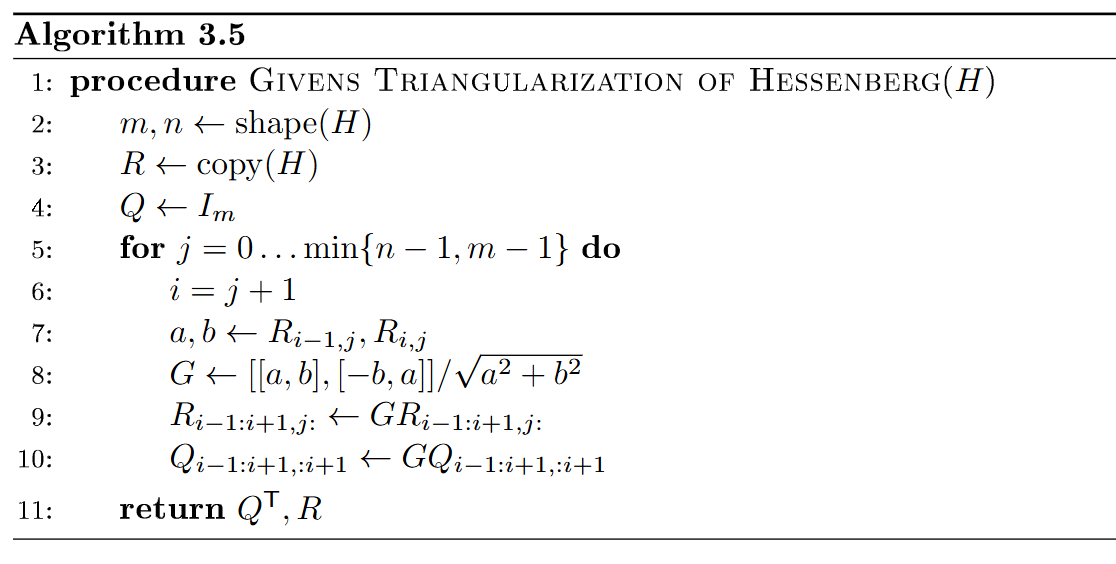

In [51]:
def QRviaGivens(H):
    m = H.shape[0]
    R = np.copy(H)
    Q_T = np.eye(m)
    for j in range(m-1):
        i = j + 1
        a = R[i-1, j]
        b = R[i, j]
        r = np.sqrt(a*a + b*b)
        c = a / r
        s = b / r
        G = np.array([[c,s],[-s,c]])
        R[i-1:i+1, j:] = G @ R[i-1:i+1, j:]
        Q_T[i-1:i+1, :i+1] = G @ Q_T[i-1:i+1,:i+1]
    return Q_T, R

In [52]:
def condition_number(A):
    largest, _ = eigsh(A, k=1, which='LA', tol=1e-10)
    smallest, _ = eigsh(A, k=1, sigma=0, which='LM', tol=1e-10)  

    return largest/smallest

In [53]:
def create_symmetric_matrix(eigenvalues):

    eigenvalues = np.array(eigenvalues)
    random_matrix = np.random.randn(10, 10)
    Q, _ = np.linalg.qr(random_matrix)
    Q = np.matrix(Q)
    D = np.diag(eigenvalues)
    A = Q @ D @ Q.T
    
    assert np.allclose(A, A.T), "Matrix is not symmetric!"
    
    return np.array(A)

In [54]:
def minres_with_iterates(A, b, maxiter=None):
    iterates = []
    
    def callback(xk):
        iterates.append(xk.copy())
    
    result = minres(A, b, rtol= 0, callback=callback)
    
    return iterates

## MINRES

In [ ]:
def MINRES(A, b, maxit=None, tol=1e-8):

    n = len(b)
    if maxit is None:
        maxit = n

    # initialise
    beta_old = 0

    q_old = np.zeros(n)
    p_1old = np.zeros(n)
    p_2old = np.zeros(n)
    x_k = np.zeros(n)

    beta0 = np.linalg.norm(b)
    q = b / beta0

    alphas = []
    betas = []
    x_list = []

    T_old = np.zeros((0, 0))

    for k in range(1, maxit + 1):

        # Lanczos
        Aq = A @ q
        alpha = np.dot(q, Aq)
        v = Aq - alpha * q - beta_old * q_old
        beta = np.linalg.norm(v)

        alphas.append(alpha)
        betas.append(beta)

        # Build T_k
        T = np.zeros((k, k))
        T[:k-1, :k-1] = T_old
        T[k-1, k-1] = alpha

        if k > 1:
            T[k-1, k-2] = betas[k-2]
            T[k-2, k-1] = betas[k-2]

        T_old = T

        # QR factorizatiot
        Q_T, R = QRviaGivens(T)
        
        if k == 1:
            p_k = q / R[0, 0]
        elif k == 2:
            p_k = (q - p_1old * R[0, 1]) / R[1, 1]
        else:
            p_k = (q - p_2old * R[k-3, k-1] - p_1old * R[k-2, k-1]) / R[k-1, k-1]


        x_k = x_k + beta0 * Q_T[k-1, 0] * p_k
        x_list.append(x_k.copy())

        if np.linalg.norm(A @ x_k - b) <= tol * beta0:
            break

        q_old = q
        q = v / beta
        beta_old = beta
        p_2old = p_1old
        p_1old = p_k

    return x_list

**Part 8:**  Next we will investigate the convergence behaviour of MINRES for symmetric matrices with different condition numbers and eigenvalue distributions.

**Same condition number/Different eigenvalue clustering**

Condition number of A is: [10.]
Condition number of B is: [10.]


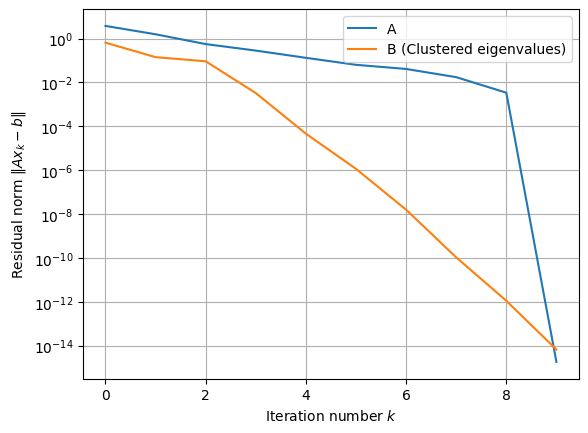

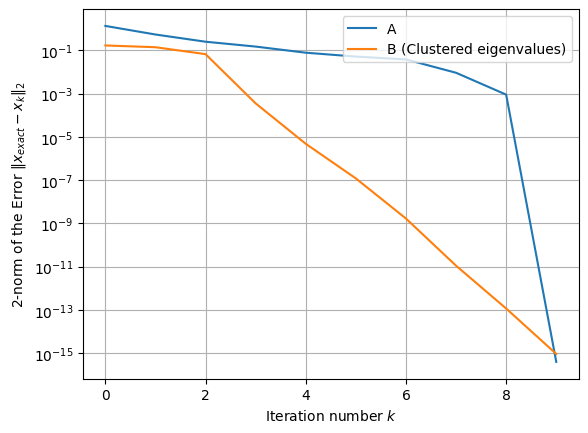

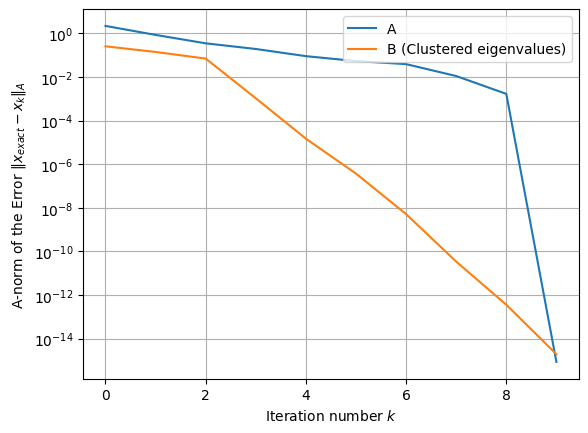

In [57]:
A_eigenvalues = np.array([10, 9, 8, 7, 6, 5, 4, 3, 2 ,1])
B_eigenvalues = np.array([10, 9.9, 9.8, 9.7, 9.6, 9.5, 9.4 ,9.3 ,9.2 ,1])

A = create_symmetric_matrix(A_eigenvalues)
B = create_symmetric_matrix(B_eigenvalues)

x_exact = np.random.randn(10)
b_A = A @ x_exact
b_B = B @ x_exact

#results_A = MINRES(A, b_A)
#results_B = MINRES(B, b_B)

results_A = minres_with_iterates(A, b_A)
results_B = minres_with_iterates(B, b_B)


print("Condition number of A is:", condition_number(A))
print("Condition number of B is:", condition_number(B))


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(b_A - A @ results_A[i]) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(b_B - B @ results_B[i]) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('Residual norm $\\|A x_k - b\\|$')
plt.legend(loc="upper right")
plt.grid(True)


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(results_A[i] - x_exact) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(results_B[i] - x_exact) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('2-norm of the Error $\\|x_{exact}  - x_k\\|_2$')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(range(len(results_A)), [np.sqrt((results_A[i] - x_exact).T @ A @ (results_A[i] - x_exact)) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.sqrt((results_B[i] - x_exact).T @ B @ (results_B[i] - x_exact)) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('A-norm of the Error $\\|x_{exact} - x_k\\|_A$')
plt.legend(loc="upper right")
plt.grid(True)

**Different condition number/Different eigenvalue clustering**

Condition number of A is: [10.]
Condition number of B is: [100.]


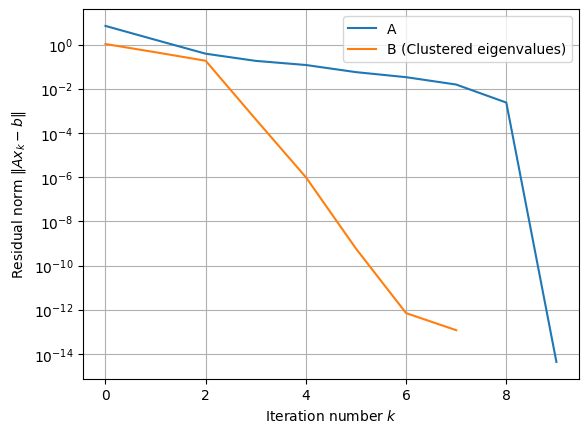

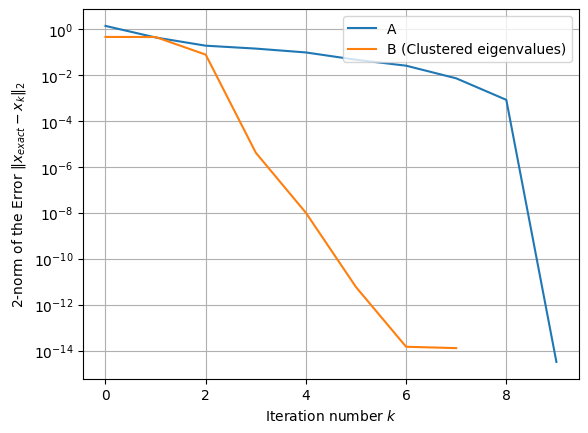

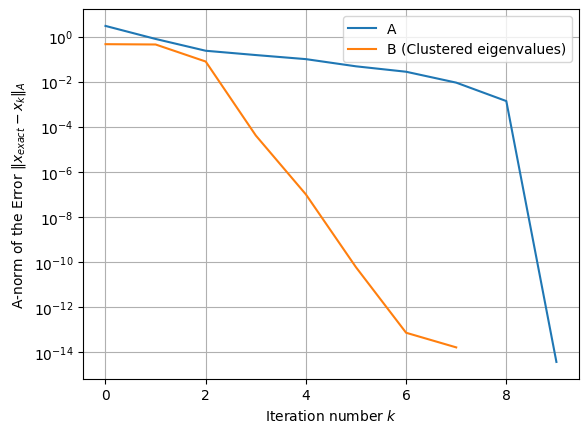

In [58]:
A_eigenvalues = np.array([10, 9, 8, 7, 6, 5, 4, 3, 2 ,1])
B_eigenvalues = np.array([100, 99.9, 99.8, 99.7, 99.6, 99.5, 99.4 ,99.3 ,99.2 ,1])

A = create_symmetric_matrix(A_eigenvalues)
B = create_symmetric_matrix(B_eigenvalues)

x_exact = np.random.randn(10)
b_A = A @ x_exact
b_B = B @ x_exact

#results_A = MINRES(A, b_A)
#results_B = MINRES(B, b_B)

results_A = minres_with_iterates(A, b_A)
results_B = minres_with_iterates(B, b_B)


print("Condition number of A is:", condition_number(A))
print("Condition number of B is:", condition_number(B))


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(b_A - A @ results_A[i]) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(b_B - B @ results_B[i]) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('Residual norm $\\|A x_k - b\\|$')
plt.legend(loc="upper right")
plt.grid(True)


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(results_A[i] - x_exact) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(results_B[i] - x_exact) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('2-norm of the Error $\\|x_{exact}  - x_k\\|_2$')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(range(len(results_A)), [np.sqrt((results_A[i] - x_exact).T @ A @ (results_A[i] - x_exact)) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.sqrt((results_B[i] - x_exact).T @ B @ (results_B[i] - x_exact)) for i in range(len(results_B))], label='B (Clustered eigenvalues)')

plt.xlabel('Iteration number $k$')
plt.ylabel('A-norm of the Error $\\|x_{exact} - x_k\\|_A$')
plt.legend(loc="upper right")
plt.grid(True)

**Different condition number/Same eigenvalue clustering**

Condition number of A is: [1000.]
Condition number of B is: [10.]


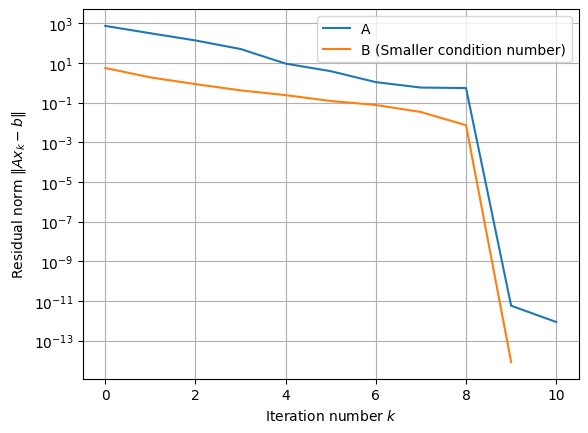

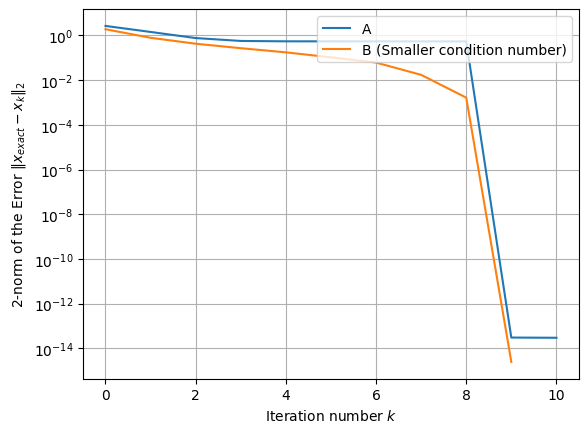

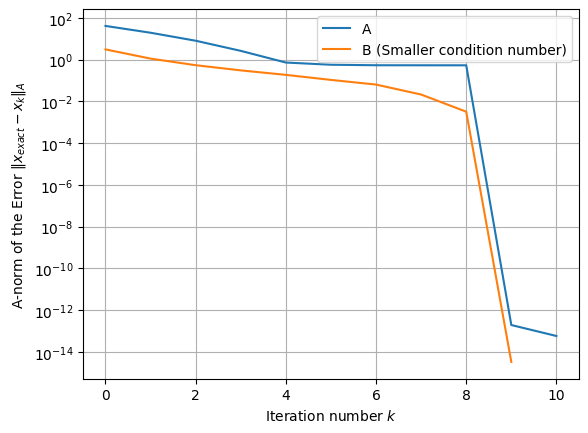

In [59]:
A_eigenvalues = np.array([1000, 900, 800, 700, 600, 500, 400, 300, 200 ,1])
B_eigenvalues = np.array([10, 9, 8, 7, 6, 5, 4, 3, 2 ,1])

A = create_symmetric_matrix(A_eigenvalues)
B = create_symmetric_matrix(B_eigenvalues)

x_exact = np.random.randn(10)
b_A = A @ x_exact
b_B = B @ x_exact

#results_A = MINRES(A, b_A)
#results_B = MINRES(B, b_B)

results_A = minres_with_iterates(A, b_A)
results_B = minres_with_iterates(B, b_B)

print("Condition number of A is:", condition_number(A))
print("Condition number of B is:", condition_number(B))


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(b_A - A @ results_A[i]) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(b_B - B @ results_B[i]) for i in range(len(results_B))], label='B (Smaller condition number)')

plt.xlabel('Iteration number $k$')
plt.ylabel('Residual norm $\\|A x_k - b\\|$')
plt.legend(loc="upper right")
plt.grid(True)


plt.figure()
plt.semilogy(range(len(results_A)), [np.linalg.norm(results_A[i] - x_exact) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.linalg.norm(results_B[i] - x_exact) for i in range(len(results_B))], label='B (Smaller condition number)')

plt.xlabel('Iteration number $k$')
plt.ylabel('2-norm of the Error $\\|x_{exact}  - x_k\\|_2$')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(range(len(results_A)), [np.sqrt((results_A[i] - x_exact).T @ A @ (results_A[i] - x_exact)) for i in range(len(results_A))], label='A')
plt.semilogy(range(len(results_B)), [np.sqrt((results_B[i] - x_exact).T @ B @ (results_B[i] - x_exact)) for i in range(len(results_B))], label='B (Smaller condition number)')

plt.xlabel('Iteration number $k$')
plt.ylabel('A-norm of the Error $\\|x_{exact} - x_k\\|_A$')
plt.legend(loc="upper right")
plt.grid(True)

**Known convergence bound relating to the condition number and eigenvalue distribution:**

$
\frac{\| b - A x_k \|_2}{\| b - A x_0 \|_2}
\le \kappa(X) \min_{p \in \mathcal{P}_k}
\max_{\lambda \in \Lambda(A)} |p(\lambda)|
$

Since $A$ is symmetric the eigenvectors are all orthogonal, meaning that $X$ (where $A = X \Lambda X^{-1}$ eigenvalue decomposition) is an orthogonal matrix, hence its condition number is equal to $1$ ($\kappa(X) = 1$), the reason is that all eigenvalues are equal to 1 in absolute value. So the bound simplifies to:

$
\frac{\| b - A x_k \|_2}{\| b - A x_0 \|_2}
\le \min_{p \in \mathcal{P}_k}
\max_{\lambda \in \Lambda(A)} |p(\lambda)|
$

**Conclusion:**

This coresponds with our plots as we can see that the more the eigenvalues are clustered together the fewer iterations it takes to converge.

**Part 9:** We compare the memory cost and computational cost of CG, MINRES, and GMRES.

Take $K$ to be the number of iterations until convergence.

The CG algorithim stores only the current needed vectors, these being the step, residual and new search direction given by $x_k,r_k,\beta_k,p_k \in \R^n$ so memory is $O(n)$. For its computational cost, at each iterations we are computing the matrix-vector product $Ap_k$ so cost is $O(Kn^2)$.

The MINRES algorithim uses the Lancosz 3-term recurrance which when implemented is $O(n)$ for both memory and cost. For overall memory, if we only were to compute only the few terms of the $Q$ and $R$ decomposition matrices that we needed at each iteration, it would overall be $O(n)$, however we did not manage to do this leading to a greater memory cost in our implementation. For its computational cost, in our 3-term recurrance we have the matrix-vector product $Aq_k$ at each iteration with no other higher order computations so our cost is $O(kn^2)$.

GMRES is different as we store the full matrix of Krylov basis vectors $Q_k$ at each iteration so if it runs for $n$ steps we would have memory cost $O(Kn)$. Since we use Arnoldi, we compute $Av_j$ as well as $j$ times the inner product $q_i^Tv$ and we do this for all $j= 1,...,k-1$, for all $k = 1,..,n$ until convergence. Thus computational cost is $O(Kn^2+K^2n)$

We can see that **between CG and MINRES, the memory and computational costs are approximately the same. GMRES however has much larger memory cost** due to storing $Q_k$ **and also computational cost** due to Arnoldi being expensive. Thus, GMRES is good in that it can deal with non-symmetric matrices however in the symmetric case it is much better to use one of the other algorithims because of the lower memory and computational cost.